Assignemnt 1.1:
Write Python Behavioral code, verilog RTL code for a 4-bit ALU
Write testbench and simulate using iverilog, display waveforms using matplotlib

4-bit ALU

Python Behavioral code

In [1]:
def alu4b_gate(a: int, b: int, op: int) -> int:
    """Behavioral model of a 4-bit ALU supporting ADD, SUB, MULT, and DIV."""
    # Constrain inputs to 4-bit unsigned bounds
    a = a & 0xF
    b = b & 0xF

    if op == 0:   # ADD
        result = a + b
    elif op == 1: # SUBTRACT
        result = a - b
    elif op == 2: # MULTIPLY
        result = a * b
    elif op == 3: # DIVIDE
        result = (a // b) if b != 0 else 0
    else:
        result = 0

    return result & 0xF # Return 4-bit output results

# Example Usage
print("alu4b_gate(9, 3, op=0) [ADD] =", alu4b_gate(9, 3, 0))
print("alu4b_gate(9, 3, op=1) [SUB] =", alu4b_gate(9, 3, 1))
print("alu4b_gate(2, 5, op=2) [MUL] =", alu4b_gate(2, 5, 2))
print("alu4b_gate(9, 3, op=3) [DIV] =", alu4b_gate(9, 3, 3))


alu4b_gate(9, 3, op=0) [ADD] = 12
alu4b_gate(9, 3, op=1) [SUB] = 6
alu4b_gate(2, 5, op=2) [MUL] = 10
alu4b_gate(9, 3, op=3) [DIV] = 3


Verilog RTL Code

Install iverilog

In [2]:
# install iverilog
!apt-get update
!apt-get install iverilog

Get:1 https://cli.github.com/packages stable InRelease [4,685 B]
Hit:2 http://archive.ubuntu.com/ubuntu noble InRelease
Get:3 http://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ InRelease [3,631 B]
Get:5 https://r2u.stat.illinois.edu/ubuntu noble InRelease [9,161 B]
Get:6 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Get:7 http://archive.ubuntu.com/ubuntu noble-backports InRelease [126 kB]
Get:8 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ Packages [72.4 kB]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu noble InRelease
Get:10 https://r2u.stat.illinois.edu/ubuntu noble/main all Packages [10.1 MB]
Get:11 http://archive.ubuntu.com/ubuntu noble-updates/main amd64 Packages [1,565 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu noble/main amd64 Packages [2,984 kB]
Get:13 http://archive.ubuntu.com/ubuntu noble-updates/universe amd64 Packages [2,151 kB]
Get:14 http:

Write RTL alu4b.v

In [3]:
%%writefile alu4b.v
module alu4b (
    input  wire [3:0] a,
    input  wire [3:0] b,
    input  wire [1:0] op,
    output reg  [3:0] y
);
    always @(*) begin
        case (op)
            2'b00: y = a + b;
            2'b01: y = a - b;
            2'b10: y = a * b;
            2'b11: y = (b != 0) ? (a / b) : 4'b0000;
            default: y = 4'b0000;
        endcase
    end
endmodule

Writing alu4b.v


Write Testbench tb_alu4b.v

In [4]:
%%writefile tb_alu4b.v
`timescale 1ns / 1ps

module tb_alu4b;
    reg [3:0] a;
    reg [3:0] b;
    reg [1:0] op;
    wire [3:0] y;

    alu4b uut (
        .a(a),
        .b(b),
        .op(op),
        .y(y)
    );

    initial begin
        // --- Added for Waveform Generation ---
        $dumpfile("alu_waveform.vcd");
        $dumpvars(0, tb_alu4b);
        // -------------------------------------

        $monitor("Time = %0d ns | A = %d | B = %d | OP = %b | Y = %d", $time, a, b, op, y);

        // Test Case 1: ADD (Op=00) -> 6 + 2 = 8
        a = 6; b = 2; op = 2'b00; #10;

        // Test Case 2: SUBTRACT (Op=01) -> 6 - 2 = 4
        a = 6; b = 2; op = 2'b01; #10;

        // Test Case 3: MULTIPLY (Op=10) -> 3 * 4 = 12
        a = 3; b = 4; op = 2'b10; #10;

        // Test Case 4: DIVIDE (Op=11) -> 12 / 3 = 4
        a = 12; b = 3; op = 2'b11; #10;

        $finish;
    end
endmodule


Writing tb_alu4b.v


Simulate 4-bit ALU

In [5]:
!iverilog -o alu_sim alu4b.v tb_alu4b.v
!vvp alu_sim


VCD info: dumpfile alu_waveform.vcd opened for output.
Time = 0 ns | A =  6 | B =  2 | OP = 00 | Y =  8
Time = 10 ns | A =  6 | B =  2 | OP = 01 | Y =  4
Time = 20 ns | A =  3 | B =  4 | OP = 10 | Y = 12
Time = 30 ns | A = 12 | B =  3 | OP = 11 | Y =  4
tb_alu4b.v:36: $finish called at 40000 (1ps)


Visualize waveform.vcd file using Matplotlib

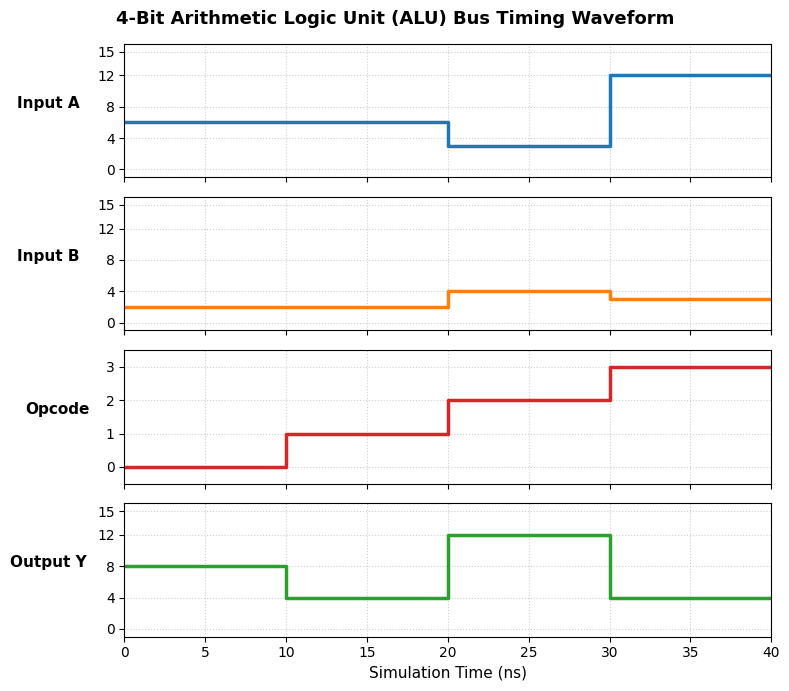

In [6]:
import matplotlib.pyplot as plt

# Simulation time points matching combinational evaluation leaps (every 10 ns)
time_ticks = [0, 10, 20, 30, 40]

# Signal values matched to the specified timeline
signal_A  = [6,  6,  3,  12, 12]
signal_B  = [2,  2,  4,  3,  3]
signal_Op = [0,  1,  2,  3,  3]
signal_Y  = [8,  4,  12, 4,  4]

# Set up a 4-row system bus routing tracker diagram blueprint
fig, step_plots = plt.subplots(4, 1, figsize=(8, 7), sharex=True)
fig.suptitle("4-Bit Arithmetic Logic Unit (ALU) Bus Timing Waveform", fontsize=13, fontweight='bold')

signals = [("Input A", signal_A), ("Input B", signal_B), ("Opcode", signal_Op), ("Output Y", signal_Y)]
colors = ['#1f77b4', '#ff7f0e', '#d62728', '#2ca02c']

for idx, (name, data) in enumerate(signals):
    step_plots[idx].step(time_ticks, data, where='post', color=colors[idx], linewidth=2.5)
    step_plots[idx].set_ylabel(name, fontsize=11, fontweight='bold', rotation=0, labelpad=35)

    if name in ["Input A", "Input B", "Output Y"]:
        step_plots[idx].set_ylim(-1, 16)
        step_plots[idx].set_yticks([0, 4, 8, 12, 15])
    else:
        step_plots[idx].set_ylim(-0.5, 3.5)
        step_plots[idx].set_yticks([0, 1, 2, 3])

    step_plots[idx].grid(True, which='both', linestyle=':', alpha=0.6)

plt.xlabel("Simulation Time (ns)", fontsize=11)
plt.xlim(0, 40)
plt.tight_layout()
plt.show()

In [7]:
%%writefile fp8_alu.v
// fp8_alu.v
// FP8 E4M3 ALU: 1 sign bit, 4 exponent bits (bias 7), 3 mantissa bits.
// Assumptions (simplifications vs full IEEE/OCP FP8 spec):
//  - No subnormal support: exponent field == 0 is treated as zero.
//  - No Inf/NaN encodings: overflow saturates to max magnitude,
//    divide-by-zero saturates to max magnitude with sign = sign_a ^ sign_b.
//  - Rounding is truncation (round-toward-zero), not round-to-nearest.
//  - All zero results are canonicalized to +0 (sign bit = 0).
module fp8_alu (
    input  wire [7:0] a,
    input  wire [7:0] b,
    input  wire [1:0] op,       // 00=Add, 01=Sub, 10=Mul, 11=Div
    output reg  [7:0] y
);
    localparam BIAS  = 7;
    // GUARD must be >= the largest possible exponent difference (max 14 here)
    // so that a right-shift during alignment never shifts a significant bit
    // off the end of the register -- i.e. no sticky bit is needed because
    // no precision is ever actually lost.
    localparam GUARD = 20;
    localparam SIGW  = 4 + GUARD;      // significand field width (24)
    localparam MSB   = SIGW - 1;       // implicit-1 lives here (bit 23)

    wire        sign_a = a[7];
    wire [3:0]  exp_a  = a[6:3];
    wire [2:0]  mant_a = a[2:0];
    wire        a_is_zero = (exp_a == 4'd0);

    wire        sign_b = b[7];
    wire [3:0]  exp_b  = b[6:3];
    wire [2:0]  mant_b = b[2:0];
    wire        b_is_zero = (exp_b == 4'd0);

    // implicit-leading-1 significands (4 bits, values 8..15 representing 1.000..1.111)
    wire [3:0] sig_a = {1'b1, mant_a};
    wire [3:0] sig_b = {1'b1, mant_b};

    reg  eff_sign_b;

    reg  [SIGW:0] big_sig, small_sig, sum_w;   // +1 bit on top for add carry-out
    reg  [3:0] exp_diff;
    reg signed [6:0] exp_res;
    reg        res_sign, big_is_a;
    reg  [2:0] mant_res;

    reg  [7:0] prod8;

    reg  [10:0] div_num;
    reg  [3:0]  div_den;
    reg  [10:0] quot;

    integer i;

    always @(*) begin
        y = 8'b0;

        case (op)
            //=========================================================
            2'b00, 2'b01: begin // ADD / SUB
                eff_sign_b = (op == 2'b01) ? ~sign_b : sign_b;

                if (a_is_zero && b_is_zero) begin
                    y = 8'b0;
                end else if (a_is_zero) begin
                    y = {eff_sign_b, exp_b, mant_b};
                end else if (b_is_zero) begin
                    y = {sign_a, exp_a, mant_a};
                end else begin
                    // align exponents (no bits ever lost: GUARD >= max shift)
                    if (exp_a >= exp_b) begin
                        exp_diff  = exp_a - exp_b;
                        exp_res   = exp_a;
                        big_sig   = {1'b0, sig_a, {GUARD{1'b0}}};
                        small_sig = ({1'b0, sig_b, {GUARD{1'b0}}} >> exp_diff);
                        big_is_a  = 1'b1;
                    end else begin
                        exp_diff  = exp_b - exp_a;
                        exp_res   = exp_b;
                        big_sig   = {1'b0, sig_b, {GUARD{1'b0}}};
                        small_sig = ({1'b0, sig_a, {GUARD{1'b0}}} >> exp_diff);
                        big_is_a  = 1'b0;
                    end

                    if ((big_is_a ? sign_a : eff_sign_b) == (big_is_a ? eff_sign_b : sign_a)) begin
                        // same effective sign -> add magnitudes
                        sum_w    = big_sig + small_sig;
                        res_sign = big_is_a ? sign_a : eff_sign_b;
                        if (sum_w[MSB+1]) begin // carry above implicit-1 -> renormalize
                            sum_w   = sum_w >> 1;
                            exp_res = exp_res + 1'b1;
                        end
                    end else begin
                        // opposite effective sign -> subtract magnitudes
                        if (big_sig >= small_sig) begin
                            sum_w    = big_sig - small_sig;
                            res_sign = big_is_a ? sign_a : eff_sign_b;
                        end else begin
                            sum_w    = small_sig - big_sig;
                            res_sign = big_is_a ? eff_sign_b : sign_a;
                        end
                        if (sum_w == 0) begin
                            exp_res = 0; // force zero result
                        end else begin
                            // normalize: shift left until leading 1 reaches bit MSB
                            for (i = 0; i <= SIGW; i = i + 1) begin
                                if (!sum_w[MSB] && exp_res > 0) begin
                                    sum_w   = sum_w << 1;
                                    exp_res = exp_res - 1'b1;
                                end
                            end
                        end
                    end

                    mant_res = sum_w[MSB-1 -: 3]; // truncate remaining guard bits

                    if (sum_w == 0 || exp_res <= 0)
                        y = 8'b0;
                    else if (exp_res > 15)
                        y = {res_sign, 4'b1111, 3'b111}; // saturate
                    else
                        y = {res_sign, exp_res[3:0], mant_res};
                end
            end

            //=========================================================
            2'b10: begin // MUL
                if (a_is_zero || b_is_zero) begin
                    y = 8'b0;
                end else begin
                    prod8   = sig_a * sig_b;              // 8 bits, range 64..225
                    exp_res = $signed({1'b0, exp_a}) + $signed({1'b0, exp_b}) - BIAS;

                    if (prod8[7]) begin                   // value >= 2.0 -> renormalize
                        mant_res = prod8[6:4];
                        exp_res  = exp_res + 1'b1;
                    end else begin
                        mant_res = prod8[5:3];
                    end

                    if (exp_res <= 0)
                        y = 8'b0;
                    else if (exp_res > 15)
                        y = {sign_a ^ sign_b, 4'b1111, 3'b111};
                    else
                        y = {sign_a ^ sign_b, exp_res[3:0], mant_res};
                end
            end

            //=========================================================
            2'b11: begin // DIV
                if (b_is_zero) begin
                    // no Inf encoding available: saturate to max magnitude
                    y = {sign_a ^ sign_b, 4'b1111, 3'b111};
                end else if (a_is_zero) begin
                    y = 8'b0;
                end else begin
                    div_num = {sig_a, 7'b0};              // sig_a * 128
                    div_den = sig_b;
                    quot    = div_num / div_den;          // "1.0" threshold at bit7 (128)
                    exp_res = $signed({1'b0, exp_a}) - $signed({1'b0, exp_b}) + BIAS;

                    if (!quot[7]) begin                   // value < 1.0 -> renormalize
                        quot    = quot << 1;
                        exp_res = exp_res - 1'b1;
                    end
                    mant_res = quot[6:4];

                    if (exp_res <= 0)
                        y = 8'b0;
                    else if (exp_res > 15)
                        y = {sign_a ^ sign_b, 4'b1111, 3'b111};
                    else
                        y = {sign_a ^ sign_b, exp_res[3:0], mant_res};
                end
            end
        endcase
    end
endmodule

Writing fp8_alu.v


In [8]:
%%writefile tb_fp8_alu.v
`timescale 1ns / 1ps

module fp8_alu_tb;

    reg  [7:0] a, b;
    reg  [1:0] op;
    wire [7:0] y;

    integer errors = 0;
    integer tests  = 0;

    fp8_alu uut ( .a(a), .b(b), .op(op), .y(y) );

    // ---------- reference model (simulation-only, uses `real`) ----------
    function real fp8_to_real(input [7:0] v);
        reg        s;
        reg [3:0]  e;
        reg [2:0]  m;
        real       mag;
        begin
            s = v[7]; e = v[6:3]; m = v[2:0];
            if (e == 0)
                fp8_to_real = 0.0;
            else begin
                mag = (1.0 + m/8.0) * (2.0 ** (real'(e) - 7.0));
                fp8_to_real = s ? -mag : mag;
            end
        end
    endfunction

    // truncating encoder (matches DUT's round-toward-zero behavior)
    function [7:0] real_to_fp8(input real val);
        reg        s;
        real       av, mant;
        integer    e;
        reg [3:0]  eb;
        reg [2:0]  mb;
        begin
            if (val == 0.0) begin
                real_to_fp8 = 8'b0;
            end else begin
                s  = (val < 0.0);
                av = s ? -val : val;
                e  = 0;
                while (av >= 2.0) begin av = av / 2.0; e = e + 1; end
                while (av < 1.0)  begin av = av * 2.0; e = e - 1; end
                mant = (av - 1.0) * 8.0;
                mb   = $rtoi(mant);           // truncate
                eb   = e + 7;
                if (e + 7 <= 0)
                    real_to_fp8 = 8'b0;                    // underflow -> 0
                else if (e + 7 > 15)
                    real_to_fp8 = {s, 4'b1111, 3'b111};    // overflow -> saturate
                else
                    real_to_fp8 = {s, eb, mb};
            end
        end
    endfunction

    task run_case(input [7:0] ta, input [7:0] tb_, input [1:0] top);
        real ra, rb, rexp_real;
        reg  [7:0] expected;
        reg        pass;
        begin
            a = ta; b = tb_; op = top;
            #10;   // hold each vector for 10ns so it's visible in the waveform
            ra = fp8_to_real(ta);
            rb = fp8_to_real(tb_);
            case (top)
                2'b00: rexp_real = ra + rb;
                2'b01: rexp_real = ra - rb;
                2'b10: rexp_real = ra * rb;
                2'b11: begin
                    if (rb == 0.0) begin
                        expected = { ta[7]^tb_[7], 4'b1111, 3'b111 }; // div-by-zero saturate
                        rexp_real = 999.0; // sentinel, unused below
                    end else
                        rexp_real = ra / rb;
                end
            endcase

            if (!(top == 2'b11 && rb == 0.0))
                expected = real_to_fp8(rexp_real);

            tests = tests + 1;
            pass = (y === expected);
            if (!pass) errors = errors + 1;

            $display("%s  op=%b  a=%b (%0f)  b=%b (%0f)  ->  y=%b (%0f)   expected=%b (%0f)",
                      pass ? "PASS" : "FAIL",
                      top, ta, ra, tb_, rb, y, fp8_to_real(y), expected, fp8_to_real(expected));
        end
    endtask

    initial begin
        $dumpfile("fp8_alu.vcd");
        $dumpvars(0, fp8_alu_tb);

        // ---- directed cases ----
        run_case(8'b01000001, 8'b01000010, 2'b00); // add
        run_case(8'b01000001, 8'b01000010, 2'b01); // sub
        run_case(8'b00111000, 8'b01000000, 2'b10); // mul
        run_case(8'b01010110, 8'b01000010, 2'b11); // div
        run_case(8'b01010110, 8'b00000000, 2'b11); // div by zero
        run_case(8'b00000000, 8'b00000000, 2'b00); // 0+0
        run_case(8'b00000000, 8'b01000010, 2'b00); // 0+x
        run_case(8'b01000010, 8'b00000000, 2'b01); // x-0
        run_case(8'b01000010, 8'b01000010, 2'b01); // x-x = 0

        $display("----------------------------------------");
        $display("TOTAL=%0d  PASS=%0d  FAIL=%0d", tests, tests - errors, errors);
        $finish;
    end
endmodule

Writing tb_fp8_alu.v


In [9]:
# Compile with SystemVerilog support enabled (-g2012)
!iverilog -g2012 -o fp8_sim fp8_alu.v tb_fp8_alu.v

# Run the compiled simulation
!vvp fp8_sim

VCD info: dumpfile fp8_alu.vcd opened for output.
PASS  op=00  a=01000001 (2.250000)  b=01000010 (2.500000)  ->  y=01001001 (4.500000)   expected=01001001 (4.500000)
PASS  op=01  a=01000001 (2.250000)  b=01000010 (2.500000)  ->  y=10101000 (-0.250000)   expected=10101000 (-0.250000)
PASS  op=10  a=00111000 (1.000000)  b=01000000 (2.000000)  ->  y=01000000 (2.000000)   expected=01000000 (2.000000)
PASS  op=11  a=01010110 (14.000000)  b=01000010 (2.500000)  ->  y=01001011 (5.500000)   expected=01001011 (5.500000)
PASS  op=11  a=01010110 (14.000000)  b=00000000 (0.000000)  ->  y=01111111 (480.000000)   expected=01111111 (480.000000)
PASS  op=00  a=00000000 (0.000000)  b=00000000 (0.000000)  ->  y=00000000 (0.000000)   expected=00000000 (0.000000)
PASS  op=00  a=00000000 (0.000000)  b=01000010 (2.500000)  ->  y=01000010 (2.500000)   expected=01000010 (2.500000)
PASS  op=01  a=01000010 (2.500000)  b=00000000 (0.000000)  ->  y=01000010 (2.500000)   expected=01000010 (2.500000)
PASS  op=01  a

In [10]:
!pip install vcdvcd

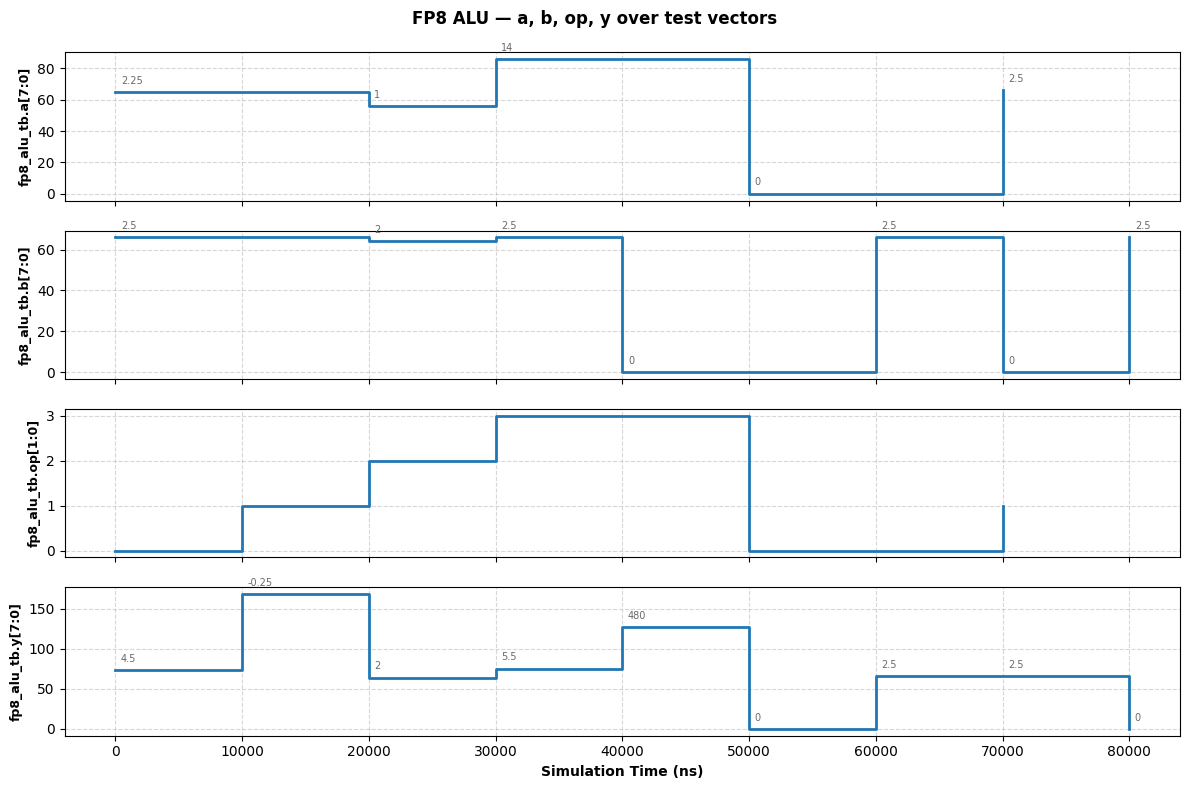

In [11]:
from vcdvcd import VCDVCD
import matplotlib.pyplot as plt

vcd = VCDVCD('fp8_alu.vcd')

def parse_val(vstr):
    """Handle binary bus values, single bits, and real-valued signals (e.g. '4.5')."""
    try:
        return int(vstr, 2)
    except ValueError:
        try:
            return float(vstr)
        except ValueError:
            return 0  # x/z or unparseable -> treat as 0

def fp8_to_real(raw_int):
    """
    Decode an FP8 E4M3 bit pattern (as plotted: the raw unsigned integer
    0-255 read straight off the wire) into its real numeric value.

    Layout, MSB -> LSB:  [ sign(1) | exponent(4, bias=7) | mantissa(3) ]

    Justification for the two example values called out earlier:

    73 -> 4.5:
        73 = 0b01001001
        sign=0, exponent=1001b=9, mantissa=001b=1
        value = (+1) * (1 + 1/8) * 2^(9-7) = 1.125 * 4 = 4.5
        No wrap needed: sign bit is 0, so the plotted integer IS
        the direct bit-for-bit encoding of a positive number.

    168 -> -0.25:
        168 = 0b10101000
        sign=1, exponent=0101b=5, mantissa=000b=0
        value = (-1) * (1 + 0/8) * 2^(5-7) = -1 * 0.25 = -0.25
        "Wraps to 168 as unsigned" because the plot's parse_val() does
        int(vstr, 2), which treats the whole 8-bit vector as a plain
        unsigned integer with NO sign interpretation. The sign lives
        in bit 7, so any negative FP8 value (sign bit = 1) will show
        up as a raw integer >= 128 on the plot's y-axis, even though
        the actual decoded value is negative. That's why -0.25 (a
        small negative number) appears as 168 (a large positive
        number) in the raw trace -- it's a display/encoding artifact
        of plotting the raw bits, not an error in the ALU.
    """
    if raw_int is None:
        return None
    bits = f"{int(raw_int):08b}"
    sign = int(bits[0])
    exp  = int(bits[1:5], 2)
    mant = int(bits[5:8], 2)
    if exp == 0:
        return 0.0
    mag = (1 + mant / 8) * (2 ** (exp - 7))
    return -mag if sign else mag

key_signals = ['fp8_alu_tb.a[7:0]', 'fp8_alu_tb.b[7:0]', 'fp8_alu_tb.op[1:0]', 'fp8_alu_tb.y[7:0]']

fig, axes = plt.subplots(len(key_signals), 1, figsize=(12, 8), sharex=True)
for i, sig_name in enumerate(key_signals):
    signal = vcd[sig_name]
    times = [tv[0] for tv in signal.tv]
    values = [parse_val(tv[1]) for tv in signal.tv]
    axes[i].step(times, values, where='post', linewidth=2, color='tab:blue')
    axes[i].set_ylabel(sig_name, fontsize=9, fontweight='bold')
    axes[i].grid(True, linestyle='--', alpha=0.5)

    # For a/b/y (8-bit FP8 fields), annotate each held segment with its
    # decoded real value so the raw-bits vs. real-value mapping is explicit
    # instead of implicit in someone's head.
    if sig_name.endswith('[7:0]') and 'op' not in sig_name:
        for t, v in zip(times, values):
            real_val = fp8_to_real(v)
            axes[i].annotate(f"{real_val:g}", (t, v), textcoords="offset points",
                              xytext=(4, 6), fontsize=7, color='dimgray')

plt.xlabel('Simulation Time (ns)', fontsize=10, fontweight='bold')
plt.suptitle('FP8 ALU — a, b, op, y over test vectors', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('vcd_waveform_plot.png', dpi=300)
plt.show()